# Spatial Econometrics — do bars drive drunk incidents in San Francisco?

**Companion to deck `05-spatial-dependence` (Part 3 — Strategy 2: Spatial model structure).**

Spatial econometrics puts spatial dependence **inside the regression equation**. We ask one real
policy question of **580 San Francisco block groups** — *does bar density raise the rate of
drunk incidents, and by how much once we account for spillover between neighbourhoods?* — and
answer it end to end.

This notebook shows, step by step, how to:
1. Build the **neighbour graph** and compare **Rook** vs **Queen** contiguity.
2. **Audit the graph** before trusting it — find the island with 0 neighbours, the park with 35, and a multipart geometry, and decide what to do with them.
3. Turn neighbour links into **weights**: binary vs **row-standardised**.
4. Explore the outcome: scatterplot, choropleth, **global Moran's I**, correlation matrix.
5. Place the model families on the **$WY$ / $WX$ / $Wu$ taxonomy** (SLX, SAR, SEM, SDM).
6. Fit **OLS with spatial diagnostics** and let the **robust LM** tests name the missing term.
7. Fit the **whole family by maximum likelihood** and rank it by **AIC**.
8. Check the lag model **actually fixed** the problem (residual Moran's I).
9. Decompose $\beta$ into **direct / indirect / total impacts** — by hand, one number at a time.
10. Convert impacts to **elasticities** so the result is legible to a non-specialist.

> Dataset: `data/incidents/InputDataset.csv` (580 block groups; drunk incidents, bar and retail
> density, poverty, demographics) joined to `data/incidents/SF_BlockGroups10.parquet`
> (NAD83 / California Albers, EPSG:3310 — already metric).
> The example follows the analysis by **Andrew Gaidus**, *Modeling San Francisco Crime Rates:
> A Spatial Econometric Approach*.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import esda                      # Moran's I, LISA
import spreg                     # spatial regression
from libpysal.graph import Graph # the modern weights/graph API

%config InlineBackend.figure_format = "retina"

SEED = 42        # fixed seed -> reproducible permutation p-values

## 1. The question and the data

Each observation is a **census block group**. The outcome and the covariates:

- **`DrunkP1k`** — drunk incidents per 1,000 residents (**the outcome**).
- **`BarPSqMi`** — bars per square mile (**the predictor of interest**).
- **`RetailPSqMi`**, **`pHHPov`** (% households in poverty), **`pMale`**, **`VacantHU`** — controls.

In [2]:
data = pd.read_csv("data/incidents/InputDataset.csv",
                   dtype={"BGFIPS10": object}).set_index("BGFIPS10")
geo  = gpd.read_parquet("data/incidents/SF_BlockGroups10.parquet").set_index("BGFIPS10")
gdf  = gpd.GeoDataFrame(data, geometry=geo.geometry, crs=geo.crs)

YVar = "DrunkP1k"
XVars = ["pHHPov", "BarPSqMi", "RetailPSqMi", "pMale", "VacantHU"]

print(f"{len(gdf)} block groups | CRS: {gdf.crs.name} (metric: {gdf.crs.is_projected})")
gdf[[YVar] + XVars].describe().round(2)

580 block groups | CRS: NAD83 / California Albers (metric: True)


,DrunkP1k,pHHPov,BarPSqMi,RetailPSqMi,pMale,VacantHU
count,580.00,580.00,580.00,580.00,580.00,580.00
mean,5.49,12.61,18.81,100.67,50.78,7.42
std,27.45,11.58,44.50,146.15,7.32,7.04
min,0.00,0.00,0.00,0.00,25.40,0.00
25%,0.00,4.15,0.00,0.00,46.08,1.62
50%,1.10,9.91,0.00,43.74,50.17,6.14
75%,3.26,17.32,21.32,139.31,54.66,11.15
max,600.00,66.41,344.94,1269.50,75.29,41.85


**Read the summary before modelling.** The outcome is severely **skewed**: median 1.1,
mean 5.5, maximum 600 drunk incidents per 1,000 people. A handful of nightlife block groups carry
most of the incidents while over a quarter record none at all.

Keep that in mind — we follow the source analysis and model the rate directly with a linear model,
which is fine for learning the spatial machinery, but a count/rate outcome with this much skew and
this many zeros would ideally get a **Poisson/negative-binomial** treatment. We return to this in
the closing caveats.

**Lesson —** look at the outcome's distribution before choosing a model: the spatial structure is
only one of the assumptions you are about to make.

## 2. Who is a neighbour? Rook vs Queen

Every spatial model starts from one decision: **who counts as a neighbour?** Two contiguity rules:

- **Rook** — polygons must share an **edge** (a border segment).
- **Queen** — sharing a **single corner** is enough.

Queen is the more common default; it is more generous, so it never has fewer neighbours than Rook.

In [3]:
rook_g  = Graph.build_contiguity(gdf, rook=True)
queen_g = Graph.build_contiguity(gdf, rook=False)

bg = "060750103003"       # an example block group
print(f"Block group {bg}")
print("  rook neighbours :", len(rook_g[bg]))
print("  queen neighbours:", len(queen_g[bg]))

Block group 060750103003
  rook neighbours : 4
  queen neighbours: 7


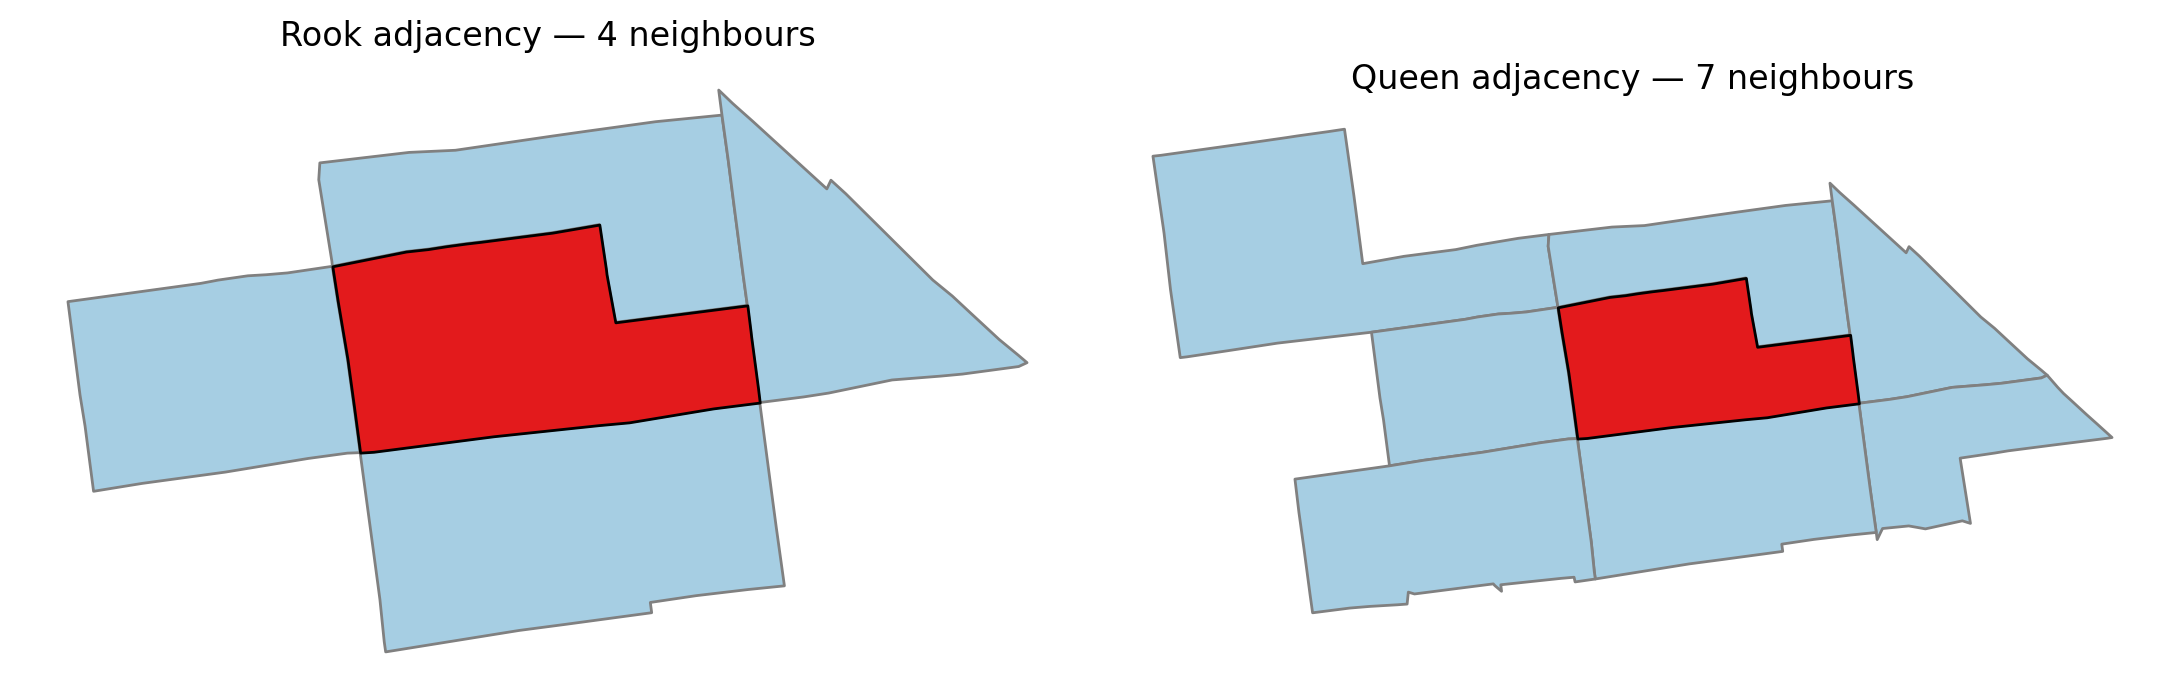

In [4]:
f, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, (name, g) in zip(ax, [("Rook", rook_g), ("Queen", queen_g)]):
    gdf.loc[list(g[bg].index)].plot(ax=a, color="#a6cee3", edgecolor="grey")
    gdf.loc[[bg]].plot(ax=a, color="#e31a1c", edgecolor="k")
    a.set_title(f"{name} adjacency — {len(g[bg])} neighbours")
    a.set_axis_off()
plt.tight_layout(); plt.show()

The red polygon is the target; blue are its neighbours. Queen finds more, because it also
accepts polygons touching at a single point. **We use Queen from here on** — the usual choice for
irregular administrative units, where a shared corner still plausibly means "next to".

**Lesson —** the neighbour rule is an assumption, not a fact: state it, and be ready to test
whether your conclusions survive the alternative.

## 3. Audit the graph before you trust it

A weights matrix built blindly can quietly wreck a model. Plot the **distribution of neighbour
counts** and look at the extremes.

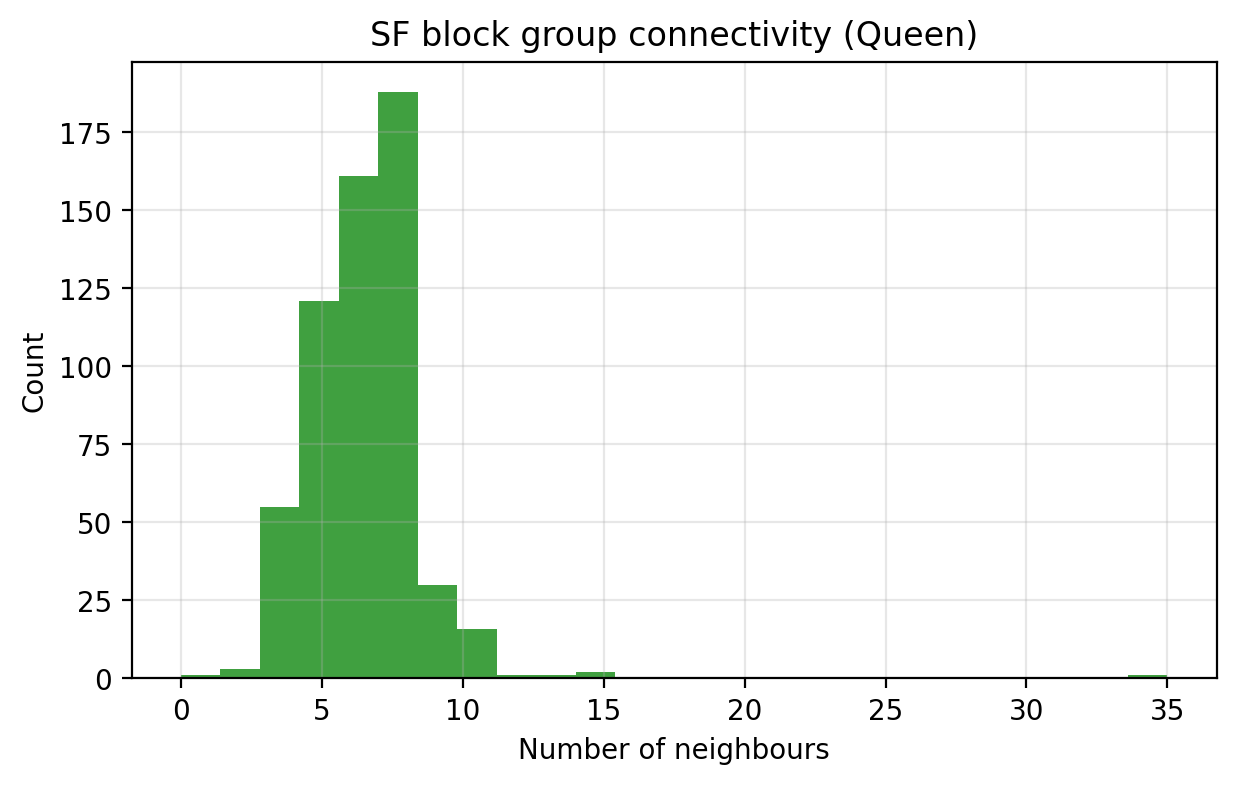

median neighbours: 6
minimum          : 0 -> ['060759804011']
maximum          : 35 -> ['060759803001']
graph components : 2


In [5]:
card = queen_g.cardinalities

plt.figure(figsize=(7, 4))
plt.hist(card.values, bins=25, facecolor="green", alpha=0.75)
plt.xlabel("Number of neighbours"); plt.ylabel("Count")
plt.title("SF block group connectivity (Queen)")
plt.grid(True, alpha=0.3); plt.show()

print("median neighbours:", int(card.median()))
print("minimum          :", card.min(), "->", list(card[card == card.min()].index))
print("maximum          :", card.max(), "->", list(card[card == card.max()].index))
print("graph components :", queen_g.n_components)

The median block group has **6** neighbours — unremarkable. The two tails are the story:
something has **0** neighbours, and something has **35**. The graph also splits into **2
components**, meaning part of the city cannot reach the rest through the neighbour network.

Both extremes turn out to be real places, and both are a problem.

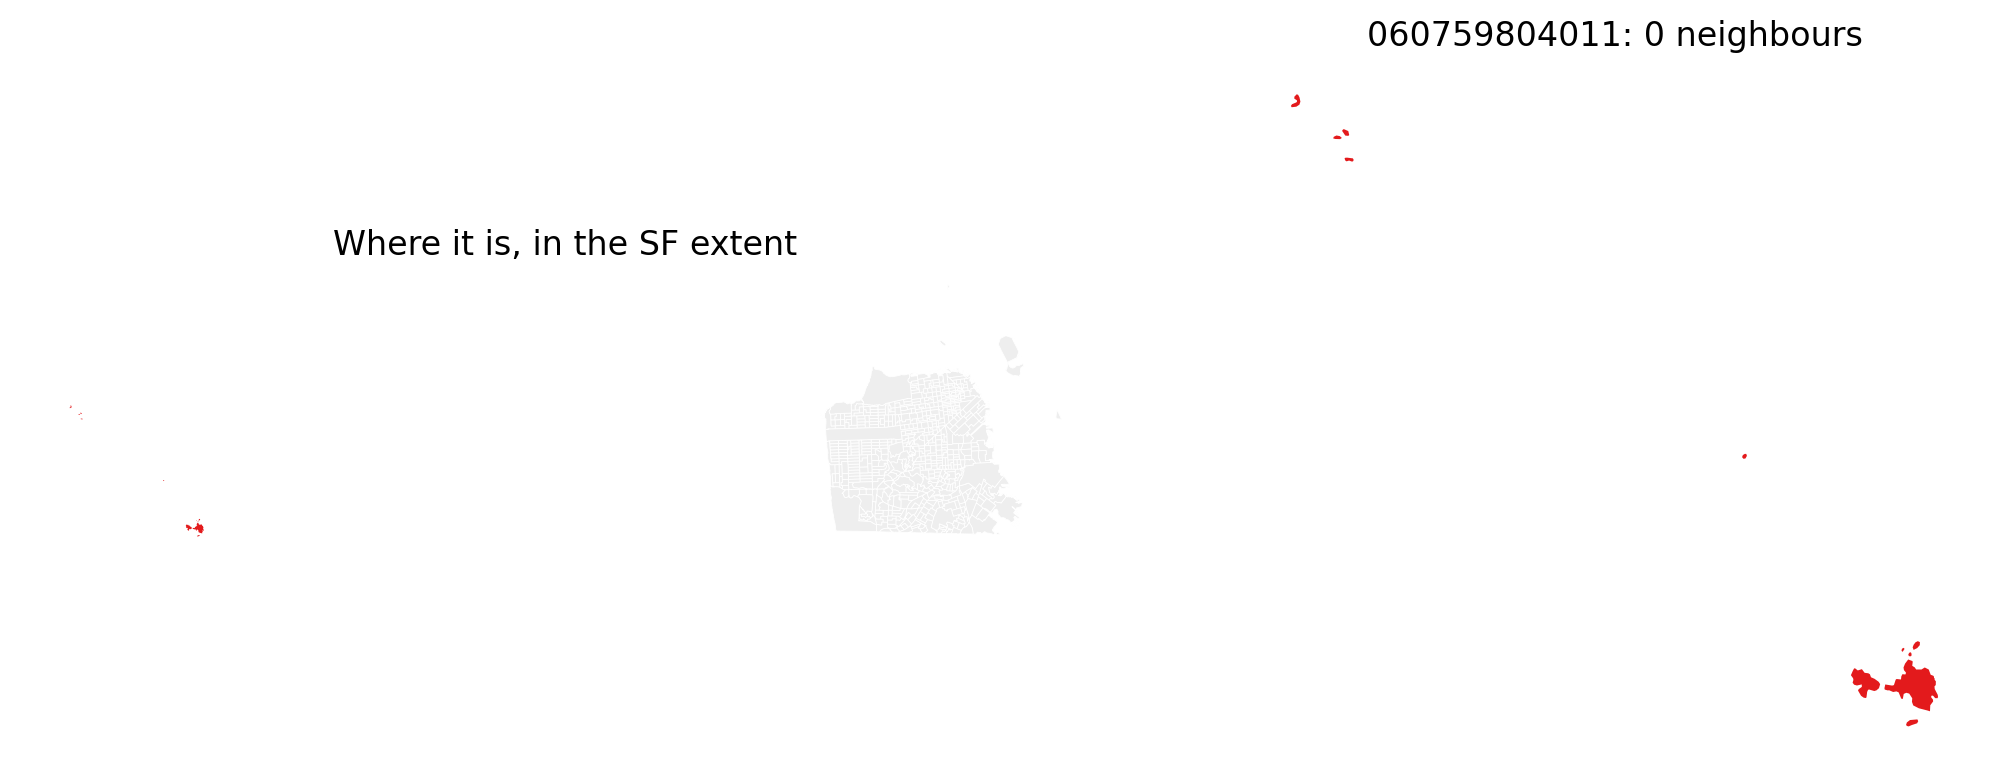

In [6]:
island_id = list(card[card == 0].index)[0]

f, ax = plt.subplots(1, 2, figsize=(11, 4))
gdf.plot(ax=ax[0], color="#eeeeee", edgecolor="white", linewidth=0.3)
gdf.loc[[island_id]].plot(ax=ax[0], color="#e31a1c")
ax[0].set_title("Where it is, in the SF extent")
gdf.loc[[island_id]].plot(ax=ax[1], color="#e31a1c")
ax[1].set_title(f"{island_id}: 0 neighbours")
for a in ax: a.set_axis_off()
plt.tight_layout(); plt.show()

**The Farallon Islands** — uninhabited rocks ~30 miles off the coast that are administratively
part of San Francisco. With no touching polygon they are an **isolate**: a row of zeros in $W$.
An isolate has no neighbours to borrow from, so a spatial lag is undefined for it — and it is why
the graph reported 2 components.

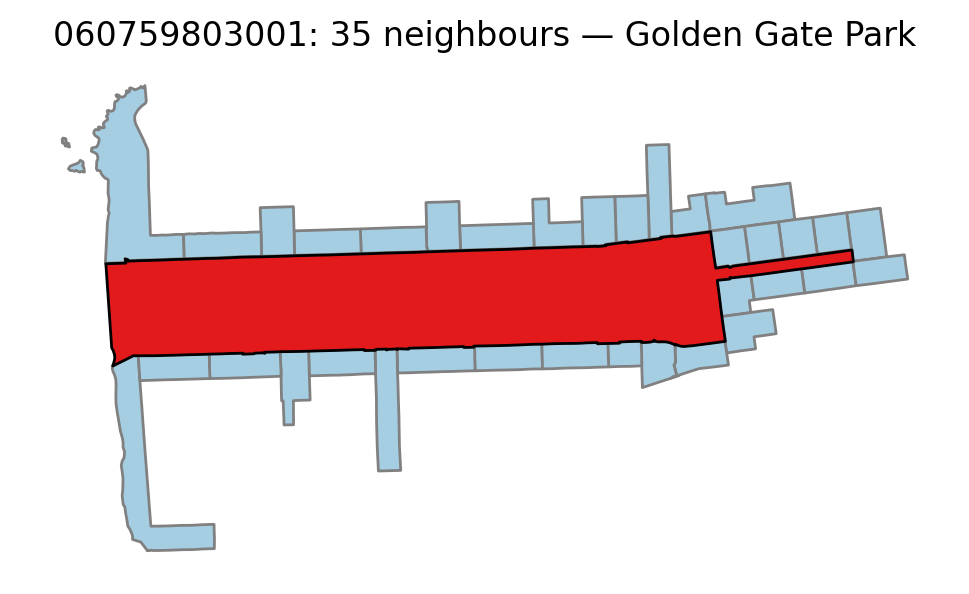

In [7]:
park_id = list(card[card == card.max()].index)[0]

f, ax = plt.subplots(figsize=(6, 5))
gdf.loc[list(queen_g[park_id].index)].plot(ax=ax, color="#a6cee3", edgecolor="grey")
gdf.loc[[park_id]].plot(ax=ax, color="#e31a1c", edgecolor="k")
ax.set_title(f"{park_id}: {card.max()} neighbours — Golden Gate Park")
ax.set_axis_off(); plt.show()

**Golden Gate Park.** A long, thin polygon slicing across the city touches **35** block groups.
Under row-standardisation each of its neighbours gets weight $1/35$ — so the park's "neighbourhood
average" is really a city-wide average, and the park is a hub that short-circuits the graph,
passing influence between parts of the city that are nowhere near each other.

It is also a park: almost nobody lives there, so its *rate per 1,000 residents* is unstable by
construction.

geometry type: MultiPolygon | parts: 10


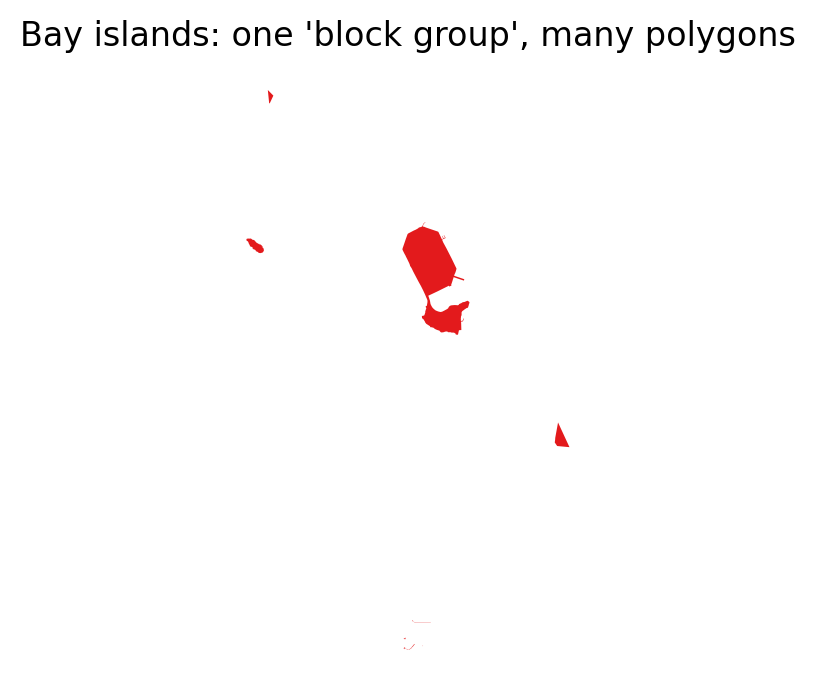

In [8]:
bay_islands = "060750179021"       # a multipart geometry: Alcatraz, Treasure Island, ...
print("geometry type:", gdf.loc[bay_islands].geometry.geom_type,
      "| parts:", len(gdf.loc[bay_islands].geometry.geoms))

f, ax = plt.subplots(figsize=(5, 4))
gdf.loc[[bay_islands]].plot(ax=ax, color="#e31a1c")
ax.set_title("Bay islands: one 'block group', many polygons"); ax.set_axis_off(); plt.show()

**The bay islands** (Alcatraz, Treasure Island and friends) are bundled into a *single*
multipart block group scattered across the water. "Contiguity" is meaningless for a unit that is
not one place.

In [9]:
drop = [island_id, park_id, bay_islands]
gdf  = gdf.drop(index=drop)

queen_g = Graph.build_contiguity(gdf, rook=False)       # rebuild on the cleaned frame
w = queen_g.to_W(); w.transform = "r"                   # bridge to the W spreg expects

print("dropped:", drop)
print(f"{len(gdf)} block groups | isolates: {len(queen_g.isolates)} "
      f"| components: {queen_g.n_components}")

dropped: ['060759804011', '060759803001', '060750179021']
577 block groups | isolates: 0 | components: 1


Removing the three gives **577 block groups, no isolates, one connected component** — a graph
every model below can actually use.

**Lesson —** audit the weights matrix before modelling: a histogram of neighbour counts and a check
for isolates and components takes a minute and catches the units where "neighbour" is a fiction.

## 4. From links to weights: binary vs row-standardised

The graph says *who* is a neighbour; the weights say *how much each neighbour counts*.

- **Binary** — every neighbour gets a 1. The spatial lag $Wy$ is then a **sum**, so a block group
  with 10 neighbours gets a lag ten times larger than one with a single neighbour — the value
  depends on how connected you are, not just on your surroundings.
- **Row-standardised** (`transform="r"`) — each row is divided by its number of neighbours, so the
  weights sum to 1 and $Wy$ becomes the **neighbourhood average**. Comparable across units.

In [10]:
wb = queen_g.to_W()                       # binary
print("binary weights for", bg, "->", wb[bg])

wr = queen_g.to_W(); wr.transform = "r"   # row-standardised
print("row-standardised   ->", {k: round(v, 3) for k, v in wr[bg].items()})
print("row sum:", round(sum(wr[bg].values()), 3))

binary weights for 060750103003 -> {'060750102002': 1, '060750103002': 1, '060750107001': 1, '060750107002': 1, '060750108001': 1, '060750109001': 1, '060750109002': 1}
row-standardised   -> {'060750102002': 0.143, '060750103002': 0.143, '060750107001': 0.143, '060750107002': 0.143, '060750108001': 0.143, '060750109001': 0.143, '060750109002': 0.143}
row sum: 1.0


Each neighbour now carries $1/n$ of the vote and the row sums to exactly 1. Every model below
uses the row-standardised $W$, which is what makes $\rho$ interpretable as "how much of the
neighbourhood average carries over".

## 5. Exploratory analysis — is there anything there?

Three questions before any model: does bar density track drunk incidents at all, is the outcome
spatially patterned, and are the covariates tangled up with each other?

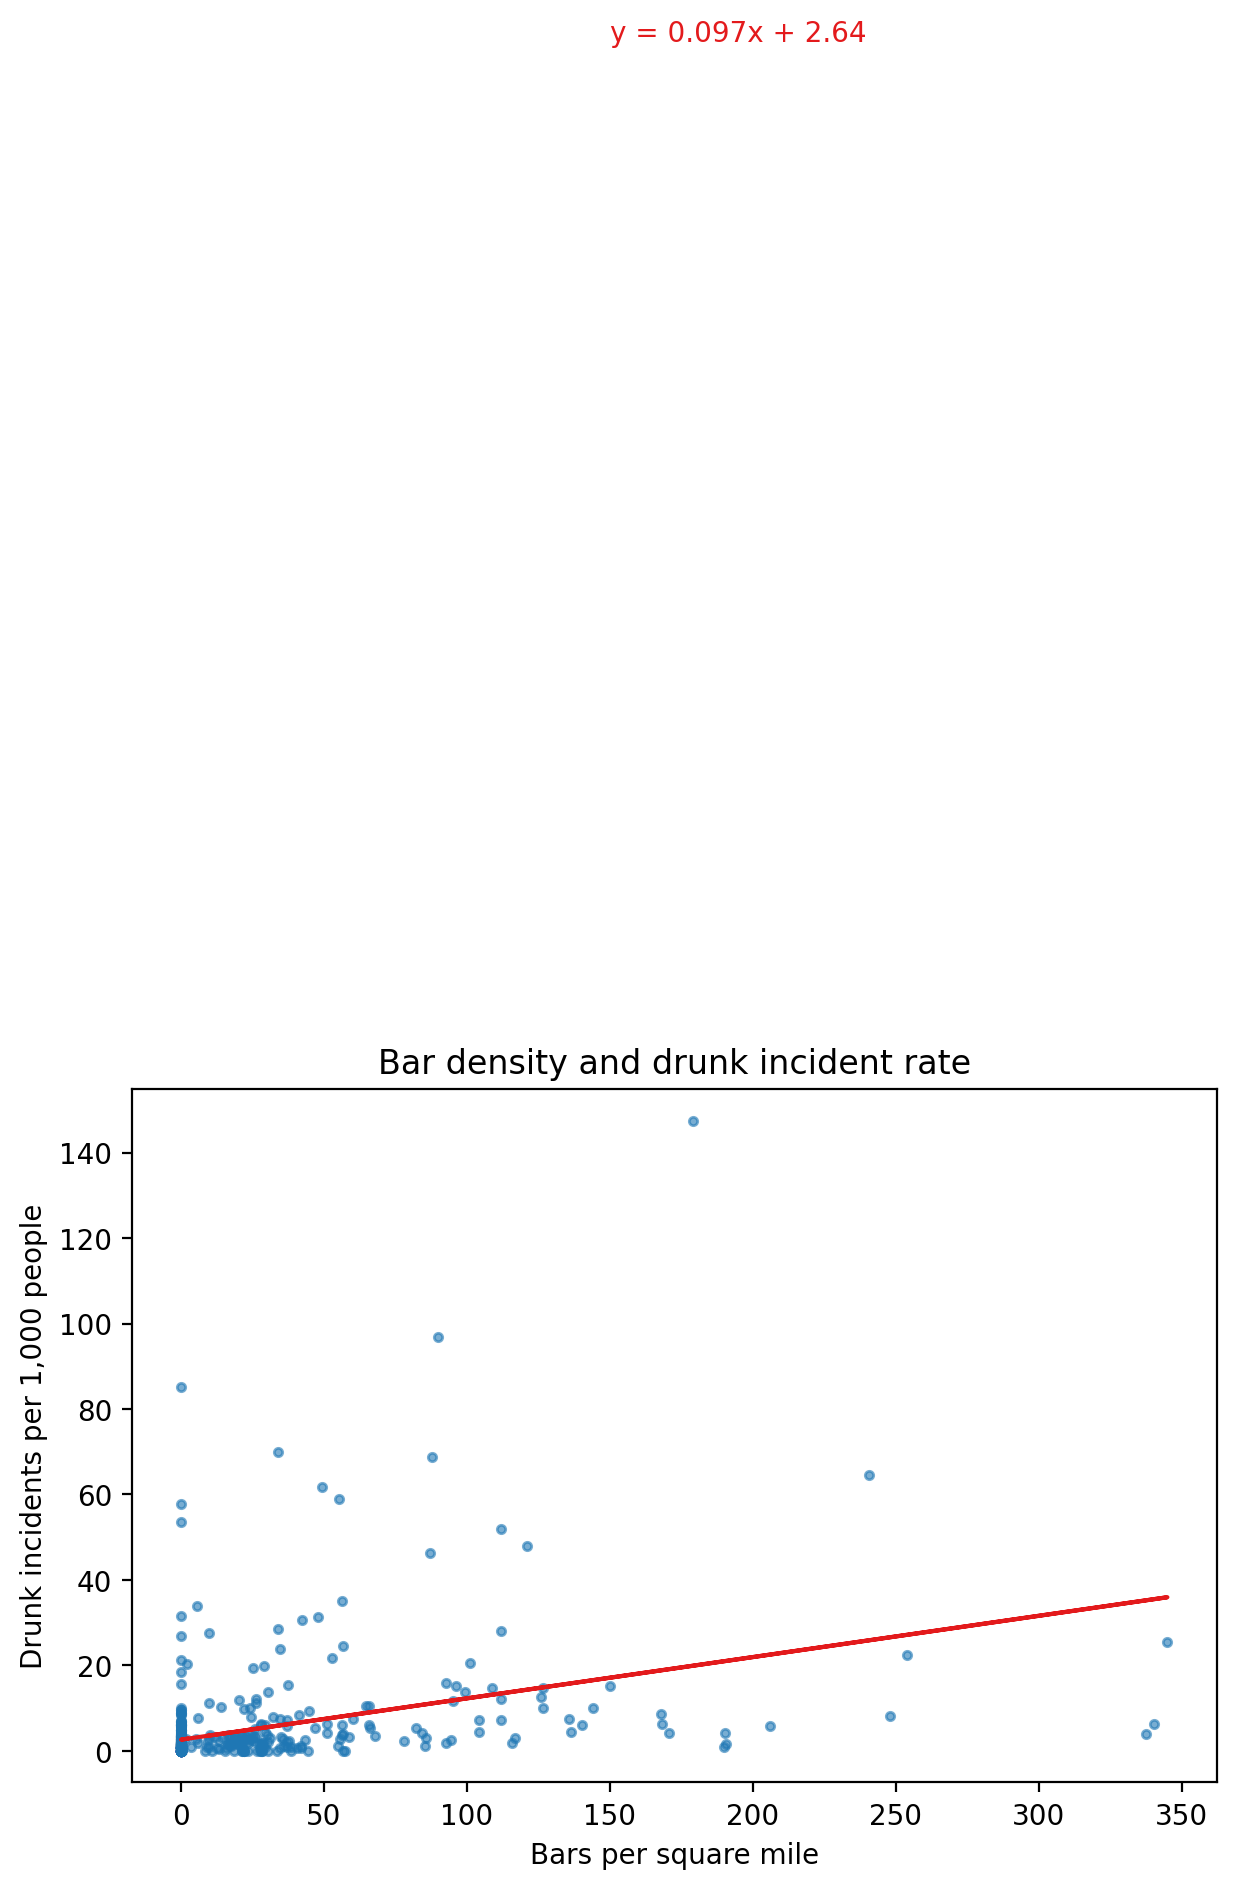

In [11]:
x, y = gdf["BarPSqMi"], gdf[YVar]
m, b_ = np.polyfit(x, y, 1)

plt.figure(figsize=(7, 4.5))
plt.plot(x, y, ".", alpha=0.6)
plt.plot(x, m * x + b_, "-", color="#e31a1c")
plt.xlabel("Bars per square mile"); plt.ylabel("Drunk incidents per 1,000 people")
plt.title("Bar density and drunk incident rate")
plt.text(150, 400, f"y = {m:.3f}x + {b_:.2f}", color="#e31a1c")
plt.show()

A clear positive slope — denser bars, more drunk incidents — but also the skew we saw in the
summary: a few extreme block groups at the top. The line is suggestive, not evidence.

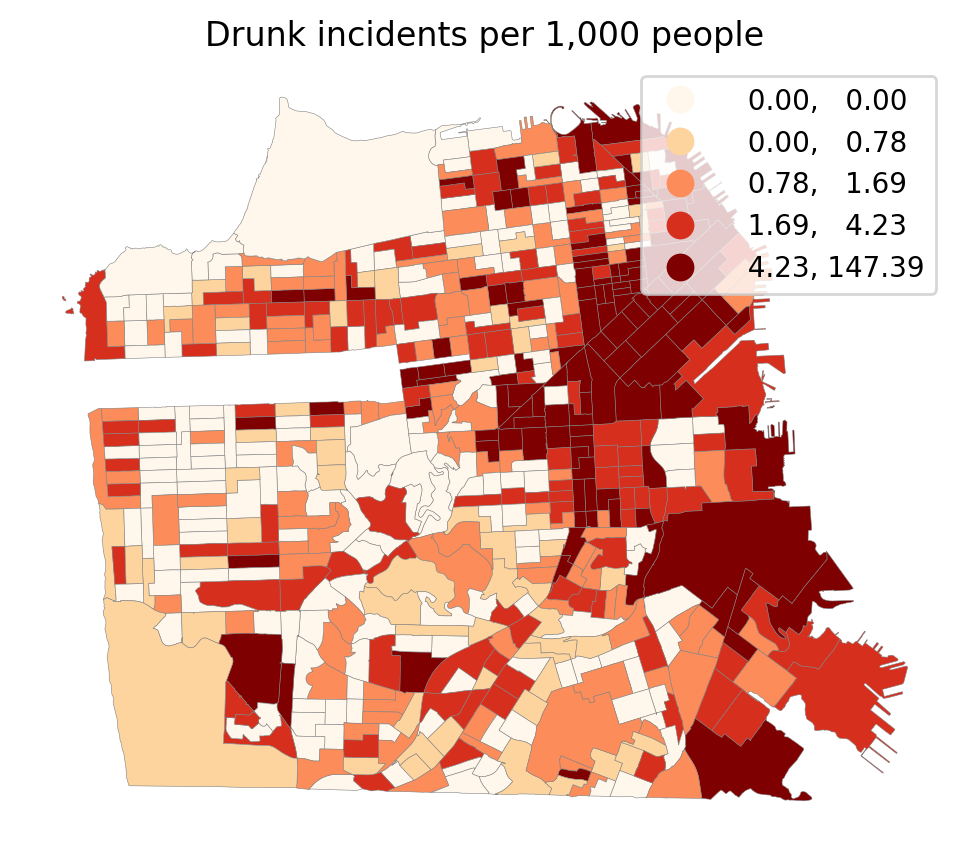

In [12]:
f, ax = plt.subplots(figsize=(6, 6))
gdf.plot(ax=ax, column=YVar, scheme="quantiles", k=5, cmap="OrRd",
         edgecolor="grey", linewidth=0.2, legend=True)
ax.set_title("Drunk incidents per 1,000 people"); ax.set_axis_off()
plt.show()

In [13]:
np.random.seed(SEED)
mi = esda.Moran(gdf[YVar], w, permutations=999)
print(f"Global Moran's I = {mi.I:.3f},  p_sim = {mi.p_sim}")

Global Moran's I = 0.384,  p_sim = 0.001


The map is visibly **not random** — the east of the city (around Market Street) is a hotspot, the
west is quiet. Moran's I $= 0.384$ with $p_{sim}=0.001$ confirms it: **drunk incidents cluster**.

That does *not* yet justify a spatial model. Clustering in the outcome may simply mean the *causes*
(bars, poverty) are themselves clustered. The question is whether structure remains **after** the
covariates do their work — which is what the OLS residuals will tell us.

**Lesson —** a clustered outcome is a reason to check the residuals, not a licence to reach
straight for a spatial model.

In [14]:
gdf[[YVar] + XVars].corr().round(2)

,DrunkP1k,pHHPov,BarPSqMi,RetailPSqMi,pMale,VacantHU
DrunkP1k,1.00,0.33,0.36,0.36,0.26,0.33
pHHPov,0.33,1.00,0.31,0.31,0.02,0.20
BarPSqMi,0.36,0.31,1.00,0.55,0.22,0.20
RetailPSqMi,0.36,0.31,0.55,1.00,0.09,0.15
pMale,0.26,0.02,0.22,0.09,1.00,0.15
VacantHU,0.33,0.20,0.20,0.15,0.15,1.00


Bar density, retail density and poverty move together — unsurprising, since they share the same
dense, central, commercial geography. Worth knowing, because it means their coefficients will
compete to explain the same variation.

## 6. The taxonomy — three kinds of spatial effect

A spatial regression can carry up to **three** distinct spatial terms (LeSage & Pace, 2009;
Elhorst, 2014). *Which* terms you switch on names the model:

- **Endogenous interaction — $\rho\,WY$:** a neighbour's **outcome** affects mine. Feedback is
  *global* — a shock loops through the whole system via $(I-\rho W)^{-1}$. → **SAR (lag)**.
- **Exogenous interaction — $WX\theta$:** a neighbour's **covariate** affects my outcome. The
  spillover is *local* (one step over the graph) and stays **OLS-estimable**. → **SLX**.
- **Error dependence — $\lambda\,Wu$:** spatially correlated **shocks** — the fingerprint of an
  omitted spatial variable. A *nuisance*: it fixes inference but carries **no spillover to
  interpret**. → **SEM (error)**.

| Model | $\rho WY$ (endogenous) | $WX\theta$ (exogenous) | $\lambda Wu$ (error) |
|---|:---:|:---:|:---:|
| **OLS** | – | – | – |
| **SLX** | – | ✓ | – |
| **SAR** (lag) | ✓ | – | – |
| **SEM** (error) | – | – | ✓ |
| **SDM** (Durbin) | ✓ | ✓ | – |
| **SDEM** | – | ✓ | ✓ |
| **SAC / SARAR** | ✓ | – | ✓ |

Substantively: is a block group rowdy because **its neighbours are rowdy** (endogenous, $WY$), or
because **its neighbours have bars** (exogenous, $WX$), or because something unmeasured — a
nightlife district — spans several block groups at once (error, $Wu$)? We do not guess: we fit the
family and let the diagnostics and AIC decide.

## 7. OLS with spatial diagnostics

Fit the non-spatial baseline first. Its **residuals** are the evidence: if they are spatially
clean, OLS is defensible and we stop. If not, the LM tests name the missing term.

In [15]:
Y = gdf[[YVar]].values
X = gdf[XVars].values

np.random.seed(SEED)
ols = spreg.OLS(Y, X, w=w, spat_diag=True, moran=True, name_y=YVar, name_x=XVars)

diag = pd.DataFrame(
    {"statistic": [ols.moran_res[0], ols.lm_lag[0], ols.rlm_lag[0],
                   ols.lm_error[0], ols.rlm_error[0]],
     "p-value":   [ols.moran_res[2], ols.lm_lag[1], ols.rlm_lag[1],
                   ols.lm_error[1], ols.rlm_error[1]]},
    index=["Moran's I (residuals)", "LM-lag", "robust LM-lag",
           "LM-error", "robust LM-error"]).round(4)
print(f"OLS R-squared = {ols.r2:.3f}")
diag

OLS R-squared = 0.286


,statistic,p-value
Moran's I (residuals),0.2224,0.0000
LM-lag,102.1072,0.0000
robust LM-lag,16.9288,0.0000
LM-error,86.2167,0.0000
robust LM-error,1.0382,0.3082


**Read it in order.**

1. **Residual Moran's I $= 0.222$, $p < 0.0001$.** The covariates did *not* absorb the spatial
   pattern — OLS residuals are strongly clustered. OLS is **not** defensible here: its standard
   errors are wrong, and if a lag is present its coefficients are biased too.
2. **Which term is missing?** Both `LM-lag` and `LM-error` are hugely significant, so they cannot
   discriminate. That is exactly the situation the **robust** versions were designed for — each
   controls for the presence of the other:
   - robust **LM-lag** $= 16.93$, $p < 0.0001$ → **significant**
   - robust **LM-error** $= 1.04$, $p = 0.31$ → **not** significant

The diagnostics point clearly at the **endogenous lag** ($\rho WY$), not the error term.

**Lesson —** don't choose a spatial model by taste: fit OLS, look at the residual Moran's I, and
when both LM tests fire, let the *robust* pair name the culprit.

## 8. Fit the family, rank it by AIC

The LM tests are one line of evidence. Now fit **OLS, SLX, SAR, SEM, SDM** by maximum likelihood
and rank them by **AIC** — which rewards fit but charges for every extra parameter, so a bigger
model only wins if the data pay for it. (`slx_lags=1` adds the exogenous $WX$ block.)

In [16]:
models = {
    "OLS": spreg.OLS     (Y, X, w=w,             name_y=YVar, name_x=XVars),
    "SLX": spreg.OLS     (Y, X, w=w, slx_lags=1, name_y=YVar, name_x=XVars),
    "SAR": spreg.ML_Lag  (Y, X, w=w,             name_y=YVar, name_x=XVars),
    "SEM": spreg.ML_Error(Y, X, w=w,             name_y=YVar, name_x=XVars),
    "SDM": spreg.ML_Lag  (Y, X, w=w, slx_lags=1, name_y=YVar, name_x=XVars),
}
terms = {"OLS": "—", "SLX": "WX (exog.)", "SAR": "rho*WY (endog.)",
         "SEM": "lambda*Wu (error)", "SDM": "rho*WY + WX (both)"}

ladder = (pd.DataFrame([{"model": k, "spatial terms": terms[k],
                         "logL": round(m.logll, 1), "AIC": round(m.aic, 1)}
                        for k, m in models.items()])
          .set_index("model").sort_values("AIC"))
ladder

,spatial terms,logL,AIC
model,,,
SDM,rho*WY + WX (both),-2105.1,4234.2
SAR,rho*WY (endog.),-2111.1,4236.2
SEM,lambda*Wu (error),-2114.1,4240.2
SLX,WX (exog.),-2134.7,4291.5
OLS,—,-2152.3,4316.7


**Reading the ladder.**

- **Every spatial model beats OLS** (4316.7) — by a wide margin. Space is not optional here.
- **SLX alone (4291.5) already improves on OLS**: even a purely *exogenous* neighbour effect helps,
  before any feedback is allowed.
- **SDM (4234.2) and SAR (4236.2) are effectively tied** — a gap of 2.0 AIC points is the
  conventional threshold for "indistinguishable". SDM fits marginally better but spends **five
  extra parameters** ($WX$ for every covariate) to get there.
- **SEM (4240.2) trails SAR**, agreeing with the robust LM test that rejected the error story.

Two independent routes — robust LM and AIC — both land on the **lag**. Where they differ, AIC's
slight nod to SDM is a reminder that some *exogenous* spillover may also be present; the deck's
advice ("prefer Durbin when in doubt about exogenous spillovers") is the conservative call. We
continue with **SAR** as the parsimonious model the diagnostics named, and flag SDM as the
defensible alternative.

**Lesson —** report the whole ladder, not just your winner: a 2-point AIC gap is a tie, and saying
so is more honest than declaring a champion.

## 9. The lag model — and did it actually fix the problem?

Fitting a spatial model is not the end: we must check it **absorbed** the dependence it was hired
to handle. Re-run Moran's I on the *new* residuals.

In [17]:
sar = models["SAR"]
rho = sar.betas[-1, 0]

coefs = pd.DataFrame({"OLS": ols.betas[1:, 0], "SAR": sar.betas[1:len(XVars)+1, 0]},
                     index=XVars).round(4)
print(f"rho (spatial autoregressive parameter) = {rho:.3f}\n")
print(coefs, "\n")

np.random.seed(SEED)
mi_res = esda.Moran(sar.u.flatten(), w, permutations=999)
print(f"OLS residual Moran's I = {ols.moran_res[0]:.3f} (p = {ols.moran_res[2]:.4f})")
print(f"SAR residual Moran's I = {mi_res.I:.3f} (p_sim = {mi_res.p_sim})")

rho (spatial autoregressive parameter) = 0.467

                OLS     SAR
pHHPov       0.1900  0.1033
BarPSqMi     0.0319  0.0240
RetailPSqMi  0.0151  0.0120
pMale        0.2901  0.1762
VacantHU     0.3683  0.2809 

OLS residual Moran's I = 0.222 (p = 0.0000)
SAR residual Moran's I = 0.003 (p_sim = 0.388)


Two results worth pausing on.

**1. The lag term did its job.** Residual Moran's I collapses from **0.222 ($p<0.0001$)** to
**0.003 ($p\approx0.39$)** — indistinguishable from random. The $\rho WY$ term absorbed the spatial
structure, which is exactly what the diagnostics predicted it would. Had the residuals stayed
clustered, we would have had to revisit $W$ or the specification.

**2. OLS was biased.** Look at `BarPSqMi`: OLS says **0.0319**, SAR says **0.0240** — a **25 %
reduction** once neighbouring drunk rates are controlled for. OLS was crediting bar density with
effects that actually belonged to *the neighbourhood spilling over*. That is not a rounding
difference; it is the bias the diagnostics warned about.

**Lesson —** always re-test the residuals after fitting: a spatial model that leaves the
autocorrelation in place has not earned its extra parameters.

## 10. Interpret — why $\beta$ is *not* the effect

In a standard linear regression, changing a covariate at one observation affects the outcome
**only at that observation**. This is *not* true in a spatial lag model: with $\rho WY$ in the
equation, drunk incidents here depend on drunk incidents next door — which depend on ours. A change
therefore **propagates through the system and partly loops back**.

So $\beta = 0.024$ does not answer "what happens if this block group gets more bars?". The next
six steps build the answer one number at a time.

### Step 1 — the two ingredients

Everything below comes from just two things in the fitted lag model: the **slope coefficients**
$\beta$ and the **spatial autoregressive parameter** $\rho$.

In [18]:
# betas layout: [CONSTANT, <XVars...>, rho]
b   = sar.betas[1:len(XVars)+1, 0]      # slope coefficients
rho = sar.betas[-1, 0]                  # spatial autoregressive parameter

print(pd.Series(b, index=XVars).round(4).to_string())
print("\nrho =", round(rho, 3))

pHHPov         0.1033
BarPSqMi       0.0240
RetailPSqMi    0.0120
pMale          0.1762
VacantHU       0.2809

rho = 0.467


$\rho \approx 0.47$, and **positive**: rowdy block groups sit next to rowdy block groups, so a
change here pushes neighbours the *same* way. That number is the engine of everything that follows
— if $\rho$ were 0 the model would collapse to OLS and $\beta$ *would* be the effect.

### Step 2 — the total effect: $\beta/(1-\rho)$

Because the effect keeps bouncing around the system, the **total** effect exceeds $\beta$. It has a
simple closed form (Kim, Phipps & Anselin, 2003):

$$\text{Total effect} = \frac{\beta}{1-\rho}$$

The factor $1/(1-\rho)$ is the **spatial multiplier**.

In [19]:
total_multiplier = 1 / (1 - rho)
b_total          = b / (1 - rho)

print("total multiplier 1/(1-rho) =", round(total_multiplier, 3), "\n")
print(pd.DataFrame({"beta": b, "total": b_total}, index=XVars).round(4).to_string())

total multiplier 1/(1-rho) = 1.875 

               beta   total
pHHPov       0.1033  0.1937
BarPSqMi     0.0240  0.0449
RetailPSqMi  0.0120  0.0225
pMale        0.1762  0.3303
VacantHU     0.2809  0.5267


With $\rho=0.47$ the multiplier is **1.87** — every effect is ~87 % larger than its coefficient
suggests. For `BarPSqMi`: $\beta=0.024$ but the **total** effect is **0.045**. Reporting the bare
coefficient would describe barely half of what bar density actually does.

This formula is **exact**, not an approximation — Step 4 proves it.

### Step 3 — splitting the total: the naive way (and its trap)

The total splits in two:

- **Direct** — the effect on a block group's *own* drunk rate of changing its *own* bar density.
- **Indirect** (spillover) — the effect on *other* block groups.

The obvious split calls $\beta$ the direct effect and takes the remainder as indirect:

In [20]:
direct_naive   = b
indirect_naive = b_total - b

print(pd.DataFrame({"Direct": direct_naive, "Indirect": indirect_naive, "Total": b_total},
                   index=XVars).round(4).to_string())

             Direct  Indirect   Total
pHHPov       0.1033    0.0904  0.1937
BarPSqMi     0.0240    0.0210  0.0449
RetailPSqMi  0.0120    0.0105  0.0225
pMale        0.1762    0.1541  0.3303
VacantHU     0.2809    0.2458  0.5267


**This is the trap.** Setting `direct = beta` assumes the effect leaves the block group and never
returns. But it does return: more drunk incidents here raise the neighbours', and *their* rate is
in the equation for *ours* — so part of the effect **comes back to its origin**. That returning
piece is genuinely **direct** (it lands on the same block group), yet the naive split files it
under *indirect*.

So the naive `Direct` is too small and its `Indirect` too big. The `Total` is fine — the two errors
cancel exactly.

### Step 4 — the feedback loop, measured

To split the total *correctly* we need the **spatial multiplier matrix**:

$$M=(I-\rho W)^{-1}=I+\rho W+\rho^{2}W^{2}+\rho^{3}W^{3}+\cdots$$

Read the series left to right: the change hits the block group itself ($I$), then its neighbours
($\rho W$), then neighbours-of-neighbours ($\rho^{2}W^{2}$) — each ripple weaker, because
$|\rho|<1$. Crucially $W^{2}, W^{4}, \dots$ have **non-zero diagonals**: those are the paths that go
out and come **back**. Hence (LeSage & Pace, 2009):

- **Direct** = mean **diagonal** of $M$ × $\beta$ — own effect *including* feedback.
- **Total** = mean **row sum** of $M$ × $\beta$ — which must equal $\beta/(1-\rho)$.
- **Indirect** = total − direct.

In [21]:
W_dense = w.full()[0]                                  # dense row-standardised W
M = np.linalg.inv(np.eye(w.n) - rho * W_dense)        # (I - rho*W)^-1

direct_multiplier = np.diag(M).mean()                 # own + feedback
rowsum_multiplier = M.sum(axis=1).mean()              # total

print("average diagonal of M =", round(direct_multiplier, 4), " (> 1 -> effect loops back)")
print("average row sum of M  =", round(rowsum_multiplier, 4))
print("1/(1-rho)             =", round(total_multiplier, 4), " <- identical: Step 2 was exact")

average diagonal of M = 1.0454  (> 1 -> effect loops back)
average row sum of M  = 1.8748
1/(1-rho)             = 1.8748  <- identical: Step 2 was exact


Two things just happened.

1. **The row sum equals $1/(1-\rho)$ exactly** (1.8748 both ways). That *proves* the Step 2 formula
   — it was never an approximation.
2. **The diagonal averages 1.045, not 1.000.** That ~4.5 % is the feedback: for every unit of
   effect a block group sends out, about 0.045 returns to it. The naive split threw that away.

In [22]:
direct   = b * direct_multiplier
total    = b * rowsum_multiplier
indirect = total - direct

impacts = pd.DataFrame({"Direct": direct, "Indirect": indirect, "Total": total},
                       index=XVars).round(4)
print(impacts.to_string(), "\n")
print("indirect / direct ratio:",
      {v: round(indirect[i] / direct[i], 3) for i, v in enumerate(XVars)})

             Direct  Indirect   Total
pHHPov       0.1080    0.0857  0.1937
BarPSqMi     0.0251    0.0199  0.0449
RetailPSqMi  0.0126    0.0100  0.0225
pMale        0.1842    0.1461  0.3303
VacantHU     0.2937    0.2330  0.5267 

indirect / direct ratio: {'pHHPov': np.float64(0.793), 'BarPSqMi': np.float64(0.793), 'RetailPSqMi': np.float64(0.793), 'pMale': np.float64(0.793), 'VacantHU': np.float64(0.793)}


Compare with Step 3: `BarPSqMi` direct moves **0.0240 → 0.0251**, indirect **0.0210 → 0.0199**.
The difference *is* the feedback loop, now filed correctly.

Both conventions have names, and `spreg` computes them for you —
`GM_Lag(..., spat_impacts=["simple", "full"])` returns `simple` (the Step-3 naive split, direct
multiplier pinned at 1.0) and `full` (the Step-4 split, direct multiplier 1.045). We did it by hand
so the arithmetic is visible; in practice ask for **`full`**.

One caveat to carry: the **indirect/direct ratio is identical (≈ 0.79) for every covariate**. A
single global $\rho$ forces *all* variables to spill over in the same proportion. If theory says
bars and poverty should spill differently — and it plausibly does, since a bar draws drinkers
*across* boundaries in a way poverty does not — that is an argument for **SDM**, which AIC already
liked.

### Step 5 — read the impacts in words

Take **`BarPSqMi`** — direct **0.0251**, indirect **0.0199**, total **0.0449**:

- **Direct 0.025** — add bars to *one* block group and its *own* drunk rate rises by 0.025 per
  1,000 people per bar-per-square-mile (feedback included — which is why it slightly exceeds
  $\beta=0.024$).
- **Indirect 0.020** — that same increase **also** raises *other* block groups' rates by 0.020 in
  total. Drinkers do not respect block-group boundaries: the incidents land next door too.
- **Total 0.045** — raise bar density **everywhere** and a typical block group's rate rises by
  0.045 = its own effect **plus** every spillover it receives.

Concretely: **10 more bars per square mile ⇒ about 0.45 more drunk incidents per 1,000 people**, of
which **44 % happens outside the block group that gained the bars**. That externality is invisible
to OLS and invisible to $\beta$ — and it is precisely what a licensing authority would need to know.

**Lesson —** report **impacts, not raw $\beta$**: the spillover is not a statistical detail here,
it is the policy finding.

### Step 6 — from impacts to elasticities

An impact of 0.045 is still hard to feel: is 10 bars per square mile a lot? Is half an incident per
1,000 people? **Elasticities** strip the units out by asking a **percentage** question of the data's
own means:

> if bar density rose **10 %** above its average, what **%** change in drunk incidents follows?

In [23]:
bars_idx   = XVars.index("BarPSqMi")
mean_bars  = gdf["BarPSqMi"].mean()
mean_drunk = gdf[YVar].mean()

bars_rise  = 0.10 * mean_bars                  # a 10% increase over mean bar density
drunk_chg  = bars_rise * b_total[bars_idx]     # expected change, TOTAL effect
pct_change = drunk_chg / mean_drunk

print(f"mean bar density = {mean_bars:.2f} per sq mi | mean drunk rate = {mean_drunk:.2f} per 1k")
print(f"a 10% rise in bar density = +{bars_rise:.2f} -> drunk rate change {drunk_chg:.3f}")
print(f"=> {100*pct_change:.1f}% change from the mean drunk incident rate")

mean bar density = 18.91 per sq mi | mean drunk rate = 4.47 per 1k
a 10% rise in bar density = +1.89 -> drunk rate change 0.085
=> 1.9% change from the mean drunk incident rate


**A 10 % increase in average bar density is associated with roughly a 1.9 % increase in the drunk
incident rate** — spillovers included. That is a sentence you can put in front of a city council:
no units to explain, no coefficients to interpret.

Note we used the **total** effect deliberately. An elasticity built on $\beta$ alone would report
roughly half this figure and understate the city-wide consequence of a licensing decision.

**Lesson —** in a spatial-lag model the answer is three numbers, not one: *direct* (own area, with
feedback), *indirect* (spillover), *total* (both). Get the total from $\beta/(1-\rho)$, split it
with the multiplier's diagonal — never by assuming direct $=\beta$ — and convert to an elasticity
when the result needs to be legible.

## 11. Caveats — what this analysis does *not* license

The spatial machinery is sound; the surrounding claims need care.

- **This is not causal.** Bars are *sited* where nightlife already is. The model measures
  association, not the effect of *opening* a bar. Reverse causation and selection are wide open.
- **The outcome is a skewed count rate** (median 1.1, max 600, many zeros) fitted with a linear
  model. The spatial conclusions are robust, but a **spatial Poisson / negative-binomial** model is
  the right home for this outcome — the source analysis says the same.
- **We deleted three block groups.** Defensible (an isolate, a 35-neighbour park hub, a multipart
  island set) and *documented* — but it is a researcher choice that moved the numbers.
- **$W$ is an assumption.** Queen contiguity was a choice; the deck's advice is to re-run under
  alternatives (Rook, KNN, distance bands) and report whether conclusions survive.
- **SDM was nearly tied with SAR.** We reported both rather than hiding the runner-up.

**Lesson —** the honest write-up states the model *and* its licence: what was assumed, what was
dropped, and which question the estimate can and cannot answer.

## Recap — the workflow, end to end

| Step | What we did | Result |
|---|---|---|
| **Graph** | Queen contiguity, audited | dropped Farallon (0 nbrs), Golden Gate Park (35), bay islands → 577 BGs, 1 component |
| **Explore** | Moran's I on the outcome | $I = 0.384$, $p = 0.001$ — clustered |
| **Diagnose** | OLS + spatial diagnostics | residual $I = 0.222$ ($p<0.0001$) → OLS rejected; robust LM-lag **16.93** vs LM-error **1.04** → **lag** |
| **Select** | family by AIC | SDM 4234.2 ≈ **SAR 4236.2** < SEM 4240.2 < SLX 4291.5 < OLS 4316.7 |
| **Validate** | residual Moran's I on SAR | **0.003** ($p\approx0.39$) — dependence absorbed |
| **Interpret** | impacts from the multiplier | bars: direct 0.025, indirect 0.020, **total 0.045** |
| **Communicate** | elasticity | +10 % bar density ⇒ **+1.9 %** drunk incidents |

The through-line: **detect → diagnose → select → validate → interpret**. Every spatial term was
earned from evidence, not assumed; the model was checked after fitting, not just before; and the
final number is reported as an impact and an elasticity, because a coefficient alone would have
understated the effect by half and hidden the spillover entirely.

> References: Anselin (1988), *Spatial Econometrics: Methods and Models*; LeSage & Pace (2009),
> *Introduction to Spatial Econometrics* (impacts, SDM); Elhorst (2014) (the $WY$/$WX$/$Wu$
> taxonomy); Kim, Phipps & Anselin (2003), *Measuring the benefits of air quality improvement*
> (the spatial multiplier); Anselin & Rey (2014), *Modern Spatial Econometrics in Practice*;
> Andrew Gaidus, *Modeling San Francisco Crime Rates* (the example and data).